# Preprocess UICrit Dataset

Cleans the UICrit CSV (nulls, duplicate screen tasks, app metadata, manual drops) and saves
`data/processed/1_preprocessed/uicrit_notna.parquet` (input of notebook 2) and `data/processed/1_preprocessed/screenshots.parquet`.

# Setup

Load packages and define shared paths used throughout the notebook.

In [1]:
import ast
import base64
import json
import re
import shutil
import sys
import tarfile
import textwrap
from pathlib import Path

import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'utils' / 'paths.py').exists())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
from utils.paths import PREPROCESSED_DIR as cleaned_dir, RAW_DIR as original_dir, SCREENS_DIR as used_screens_dir
from utils.screen_display import show_screen, show_screen_grid

rating_cols = ['aesthetics_rating', 'learnability', 'efficiency', 'usability_rating', 'design_quality_rating']
general_app_identifiers = {
    'android',
    'com.android.browser',
    'com.android.gallery3d',
    'com.google.android.gms',
    'com.android.packageinstaller',
}

# Load UICrit Dataset

Read the source CSV, normalize the `efficency` column typo, and parse list-valued fields.

In [2]:
df = pd.read_csv(original_dir / 'uicrit_public.csv').rename(columns={'efficency': 'efficiency'})
df['comments'] = df['comments'].apply(ast.literal_eval)
df['comments_source'] = df['comments_source'].apply(ast.literal_eval)

print(df.shape)
print(f'Total comments: {df["comments"].apply(len).sum()}')
df.head(3)

(2981, 9)
Total comments: 11430


,rico_id,task,aesthetics_rating,learnability,efficiency,usability_rating,design_quality_rating,comments_source,comments
0,10089,Follow events to keep track on your favorite g...,6,3.0,3,6,6,"[human, human, human, human, both, both, both]",[Comment 1\nThe expected standard is that the ...
1,10089,Explore the ACC Tournament schedules and match...,6,2.0,3,5,6,"[human, human, human, human, human, human, both]",[Comment 1\nThe expected standard is to make t...
2,10089,Check the sport's schedule .,7,4.0,4,7,7,"[human, human, human, both]",[LLM Comment 1\nThe expected standard is for U...


## Basic Validity Checks

Check missing values and rating ranges, then drop rows with nulls.

In [3]:
display(df[df.isnull().any(axis=1)])

rating_ranges = {'aesthetics_rating': 10, 'learnability': 5, 'efficiency': 5, 'usability_rating': 10, 'design_quality_rating': 10}
{col: int((~df[col].between(1, hi)).sum()) for col, hi in rating_ranges.items()}

,rico_id,task,aesthetics_rating,learnability,efficiency,usability_rating,design_quality_rating,comments_source,comments
432,190,NaN,7,4.0,4,7,7,"[human, llm, both, llm]",[LLM Comment 1\nThe expected standard is The t...
1186,36445,View privacy policy and disclaimer,6,NaN,4,7,7,"[human, human, human]",[LLM Comment 1\nThe expected standard is to us...
2799,70901,NaN,6,3.0,3,6,6,"[human, human, human, human, human, both]",[Comment 1\nThe expected standard is that the ...


{'aesthetics_rating': 0,
 'learnability': 1,
 'efficiency': 0,
 'usability_rating': 0,
 'design_quality_rating': 0}

In [4]:
df = df.dropna().astype({'learnability': int}).sort_values(['rico_id', 'task']).reset_index(drop=True)

print(f'Rows after dropping nulls: {len(df)}')
print(f'Unique screens after dropping nulls: {df["rico_id"].nunique()}')
print(f'Total comments after dropping nulls: {df["comments"].apply(len).sum()}')

Rows after dropping nulls: 2978
Unique screens after dropping nulls: 1000
Total comments after dropping nulls: 11416


## Prepare Screen Assets

`data/processed/1_preprocessed/used_dataset_screens` holds the image + JSON of every screen referenced by the dataset. To rebuild it from scratch, download the RICO *UI Screenshots and View Hierarchies* archive ([interactionmining.org/rico](http://www.interactionmining.org/rico.html)) and place it at `data/raw/unique_uis.tar.gz`; only the missing screens are extracted from it.

In [5]:
expected_rico_ids = sorted(df['rico_id'].unique())
used_screens_dir.mkdir(parents=True, exist_ok=True)

missing_files = {
    name for rico_id in expected_rico_ids for name in (f'{rico_id}.jpg', f'{rico_id}.json')
    if not (used_screens_dir / name).exists()
}
if missing_files:
    archive_path = original_dir / 'unique_uis.tar.gz'
    if not archive_path.exists():
        raise FileNotFoundError(f'{len(missing_files)} screen files missing; place the RICO unique_uis.tar.gz in data/raw/.')
    with tarfile.open(archive_path) as archive:
        for member in archive:
            if member.isfile() and Path(member.name).name in missing_files:
                (used_screens_dir / Path(member.name).name).write_bytes(archive.extractfile(member).read())

missing_images = [i for i in expected_rico_ids if not (used_screens_dir / f'{i}.jpg').exists()]
missing_jsons = [i for i in expected_rico_ids if not (used_screens_dir / f'{i}.json').exists()]
if missing_images or missing_jsons:
    raise FileNotFoundError(f'Missing images: {missing_images[:10]}, missing jsons: {missing_jsons[:10]}')
print(f'All {len(expected_rico_ids)} screens have a .jpg image and a .json file.')

All 1000 screens have a .jpg image and a .json file.


# Add App Metadata

Derive app identifiers from the screen JSON `activity_name`, then map app names and categories from Play Store metadata.

In [6]:
playstore_df = pd.read_csv(original_dir / 'playstore_app_details.csv')
ui_metadata_df = pd.read_csv(original_dir / 'ui_details.csv')
assert playstore_df['App Package Name'].is_unique

playstore_by_package = playstore_df.set_index('App Package Name')


def screen_activity_metadata(rico_id):
    activity_name = json.loads((used_screens_dir / f'{rico_id}.json').read_text(encoding='utf-8')).get('activity_name')
    app_identifier, _, activity_class = (activity_name or '').partition('/')
    return {
        'rico_id': rico_id,
        'activity_name': activity_name,
        'app_identifier': app_identifier or None,
        'activity_class': activity_class or None,
        'is_general_app_identifier': app_identifier in general_app_identifiers,
    }


screen_metadata_df = pd.DataFrame([screen_activity_metadata(i) for i in expected_rico_ids])
screen_metadata_df['app'] = screen_metadata_df['app_identifier'].map(playstore_by_package['Play Store Name'])
screen_metadata_df['app_category'] = screen_metadata_df['app_identifier'].map(playstore_by_package['Category'])

df = df.merge(screen_metadata_df, on='rico_id', how='left', validate='many_to_one')
df['num_comments'] = df['comments'].apply(len)
screen_metadata_df.head()

,rico_id,activity_name,app_identifier,activity_class,is_general_app_identifier,app,app_category
0,15,se.perigee.android.seven/com.perigee.seven.ui....,se.perigee.android.seven,com.perigee.seven.ui.activity.WorkoutListActivity,False,Seven - 7 Minute Workout,Health & Fitness
1,28,com.scotiabank.mobile/com.scotiabank.mobile.Mo...,com.scotiabank.mobile,com.scotiabank.mobile.MobileBanking,False,Scotiabank Mobile Banking,Finance
2,67,gov.nasa/gov.nasa.images.PhotoPager,gov.nasa,gov.nasa.images.PhotoPager,False,NASA,Education
3,190,com.caliente.android.mobile/com.greatpersonals...,com.caliente.android.mobile,com.greatpersonalsmedia.android.activities.Sea...,False,Caliente - Latin Dating,Social
4,193,com.caliente.android.mobile/com.greatpersonals...,com.caliente.android.mobile,com.greatpersonalsmedia.android.activities.Fri...,False,Caliente - Latin Dating,Social


# Clean Screen Tasks

Remove repeated screen tasks, assign stable IDs, audit app identifiers and record the manual decisions.

## Deduplicate Exact Screen-Task Repeats

For repeated `(rico_id, task)` rows, keep the row with the most comments.

In [7]:
exact_duplicate_df = df[df.duplicated(subset=['rico_id', 'task'], keep=False)]

duplicate_review_df = (
    exact_duplicate_df.groupby(['rico_id', 'task'])
    .agg(
        app=('app', 'first'),
        comment_counts=('num_comments', list),
        rating_conflict=('rico_id', lambda idx: bool(exact_duplicate_df.loc[idx.index, rating_cols].nunique().gt(1).any())),
    )
    .reset_index()
)
duplicate_review_df['max_comment_count_tied'] = duplicate_review_df['comment_counts'].apply(lambda c: c.count(max(c)) > 1)

print(f'Exact repeated (rico_id, task) groups: {len(duplicate_review_df)}')
print(f'Rows involved: {len(exact_duplicate_df)}')
display(duplicate_review_df)

Exact repeated (rico_id, task) groups: 19
Rows involved: 38


,rico_id,task,app,comment_counts,rating_conflict,max_comment_count_tied
0,190,Click the 'Chat' button to initiate a conversa...,Caliente - Latin Dating,"[3, 3]",True,True
1,1693,View the list of gas stations,Pure Gas,"[2, 1]",True,False
2,6966,View the download history,ComicScreen - ComicViewer,"[2, 2]",True,True
3,12757,Entry Page to enable Drivemode,Drivemode: Driving interface,"[2, 2]",True,True
4,12773,Proceed to next page on onboarding screen,FalloutCrafter Addon MCPE Mod,"[3, 2]",True,False
5,18491,Manage Settings.,SuperVchat,"[4, 4]",True,True
6,20894,Enter username and password to sign in,SPG: Starwood Hotels & Resorts,"[6, 3]",True,False
7,24599,Read about the new version,Paint Photo Editor,"[6, 4]",True,False
8,25399,View or search Japanese recipes,Japanese Recipes,"[2, 4]",True,False
9,26551,Click to play/learn the Guitar chord,GChord (Guitar Chord Finder),"[5, 1]",True,False


In [8]:
idx_to_keep = exact_duplicate_df.groupby(['rico_id', 'task'])['num_comments'].idxmax()
rows_to_drop = exact_duplicate_df.index.difference(idx_to_keep)

display(df.loc[rows_to_drop, ['rico_id', 'app_identifier', 'app', 'task', 'num_comments'] + rating_cols])
df = df.drop(index=rows_to_drop).reset_index(drop=True)

print(f'Rows dropped as exact repeated screen-task pairs: {len(rows_to_drop)}')
print(f'Rows after exact duplicate cleanup: {len(df)}')
print(f'Unique screens after exact duplicate cleanup: {df["rico_id"].nunique()}')

,rico_id,app_identifier,app,task,num_comments,aesthetics_rating,learnability,efficiency,usability_rating,design_quality_rating
10,190,com.caliente.android.mobile,Caliente - Latin Dating,Click the 'Chat' button to initiate a conversa...,3,6,3,3,6,6
76,1693,com.AutoLean.puregas,Pure Gas,View the list of gas stations,1,5,3,3,5,5
301,6966,com.viewer.comicscreen,ComicScreen - ComicViewer,View the download history,2,4,3,3,6,5
560,12757,com.drivemode.android,Drivemode: Driving interface,Entry Page to enable Drivemode,2,5,4,4,5,5
562,12773,minecraft.falloutcrafter.mod,FalloutCrafter Addon MCPE Mod,Proceed to next page on onboarding screen,2,6,3,3,6,6
807,18491,com.SuperVchat,SuperVchat,Manage Settings.,4,6,3,3,5,6
895,20894,com.starwood.spg,SPG: Starwood Hotels & Resorts,Enter username and password to sign in,3,4,4,4,4,4
992,24599,com.dmpaintfree,Paint Photo Editor,Read about the new version,4,5,2,3,5,5
1022,25399,com.endless.japaneserecipes,Japanese Recipes,View or search Japanese recipes,2,7,3,3,6,7
1070,26551,jp.ne.asoft.android.gchord,GChord (Guitar Chord Finder),Click to play/learn the Guitar chord,1,5,3,3,5,5


Rows dropped as exact repeated screen-task pairs: 19
Rows after exact duplicate cleanup: 2959
Unique screens after exact duplicate cleanup: 1000


## Assign Screen-Task IDs

Generate deterministic IDs (`<rico_id>_T<nn>`) after exact duplicate cleanup and before manual drops, so later manual decisions can reference them.

In [9]:
df.insert(0, 'screen_task_id', df['rico_id'].astype(str) + '_T' + (df.groupby('rico_id').cumcount() + 1).map('{:02d}'.format))
assert df['screen_task_id'].is_unique

print(f'Max number of tasks per screen: {df.groupby("rico_id").size().max()}')
df[['screen_task_id', 'rico_id', 'task']].head()

Max number of tasks per screen: 4


,screen_task_id,rico_id,task
0,15_T01,15,Plan and Start Full Body Workouts
1,15_T02,15,Tap on the Plus icon or explore the Workout Pl...
2,15_T03,15,select and get started with Full body workouts
3,28_T01,28,Enter details to Sing In to Scotiabank.
4,28_T02,28,Enter details to sign in or click on activate ...


## Validate Rico ID Against App Identifier

For each `rico_id`, check whether `ui_details.csv` contains the same `(UI Number, App Package Name)` pair as the screen JSON.

In [10]:
screen_task_summary_df = (
    df.groupby('rico_id')
    .agg(screen_task_ids=('screen_task_id', list), tasks=('task', list), num_screen_tasks=('screen_task_id', 'size'))
    .reset_index()
)
ui_pairs = set(zip(ui_metadata_df['UI Number'], ui_metadata_df['App Package Name']))
app_to_candidate_ui_numbers = ui_metadata_df.groupby('App Package Name')['UI Number'].agg(lambda v: sorted(v.unique()))

screen_app_check_df = screen_metadata_df.merge(screen_task_summary_df, on='rico_id')
screen_app_check_df['rico_id_app_identifier_mismatch'] = [
    app is not None and (rico_id, app) not in ui_pairs
    for rico_id, app in zip(screen_app_check_df['rico_id'], screen_app_check_df['app_identifier'])
]

rico_id_app_mismatch_df = screen_app_check_df[screen_app_check_df['rico_id_app_identifier_mismatch']].copy()
rico_id_app_mismatch_df['candidate_ui_numbers_same_app'] = rico_id_app_mismatch_df['app_identifier'].map(app_to_candidate_ui_numbers)

print(f'Rico ID / app identifier mismatches: {len(rico_id_app_mismatch_df)}')
print(f'General/system identifier mismatches: {rico_id_app_mismatch_df["is_general_app_identifier"].sum()}')
display(
    rico_id_app_mismatch_df[
        ['rico_id', 'screen_task_ids', 'tasks', 'app_identifier', 'app', 'app_category',
         'activity_class', 'is_general_app_identifier', 'candidate_ui_numbers_same_app']
    ].sort_values(['is_general_app_identifier', 'app_identifier', 'rico_id'])
)

Rico ID / app identifier mismatches: 41
General/system identifier mismatches: 27


,rico_id,screen_task_ids,tasks,app_identifier,app,app_category,activity_class,is_general_app_identifier,candidate_ui_numbers_same_app
899,64676,"[64676_T01, 64676_T02, 64676_T03]","[Manage settings for the app, Set your prefere...",com.appxy.tinyscanner,Tiny Scanner - PDF Scanner App,Business,com.appxy.tinyscanfree.Activity_Setting,False,"[60291, 60292, 60293]"
534,38731,"[38731_T01, 38731_T02, 38731_T03]","[Choose an option to proceed, Click ""Get Start...",com.asanayoga.asanarebel,NaN,NaN,com.asanayoga.asanarebel.ui.onboarding.IntroVi...,False,NaN
878,63468,"[63468_T01, 63468_T02, 63468_T03]","[Invite friends or share the episode of ""Reign...",com.cw.fullepisodes.android,The CW,Entertainment,com.cw.fullepisodes.android.activity.VideoPlay...,False,"[23422, 23423, 23424, 23425, 23426, 23427, 234..."
8,422,"[422_T01, 422_T02, 422_T03]",[Click to continue to signup with facebook pro...,com.facebook.katana,Facebook,Social,com.facebook.gdp.LightWeightProxyAuthActivity,False,"[8993, 8994, 8995, 8996, 8997, 8998, 8999, 900..."
220,14699,"[14699_T01, 14699_T02, 14699_T03]","[Enter details for login/sign up account., Ent...",com.facebook.katana,Facebook,Social,com.facebook.gdp.LightWeightProxyAuthActivity,False,"[8993, 8994, 8995, 8996, 8997, 8998, 8999, 900..."
298,20803,"[20803_T01, 20803_T02, 20803_T03]","[Link Facebook account to sonic, Sign in with ...",com.facebook.katana,Facebook,Social,com.facebook.gdp.LightWeightProxyAuthActivity,False,"[8993, 8994, 8995, 8996, 8997, 8998, 8999, 900..."
306,21267,"[21267_T01, 21267_T02, 21267_T03]","[Write a Facebook post to share with friends, ...",com.facebook.katana,Facebook,Social,com.facebook.platform.composer.composer.Platfo...,False,"[8993, 8994, 8995, 8996, 8997, 8998, 8999, 900..."
891,64091,"[64091_T01, 64091_T02, 64091_T03]",[Click 'Continue as Jon' or sign in with anoth...,com.facebook.katana,Facebook,Social,com.facebook.gdp.LightWeightProxyAuthActivity,False,"[8993, 8994, 8995, 8996, 8997, 8998, 8999, 900..."
259,17718,"[17718_T01, 17718_T02, 17718_T03]","[Search or set your destination., Set destinat...",com.here.app.maps,HERE WeGo - Offline Maps & GPS,Maps & Navigation,com.here.app.MainActivity,False,"[15125, 15126, 15127, 15128, 15129, 15130, 151..."
552,40161,"[40161_T01, 40161_T02]","[Explore prayer to view, Set prayer time]",com.mobileappsteam.myprayer,"My Prayer: Qibla, Athan, Quran",Lifestyle,com.mobileappsteam.myprayer.activities.MainAct...,False,"[46049, 46050, 46051]"


## Inspect Screens by App Identifier

List app identifiers with missing/general metadata or rico-id mismatches, then display the screens of one identifier to confirm the grouping is visually coherent.

In [11]:
problem_mask = (
    screen_app_check_df['app'].isna()
    | screen_app_check_df['app_category'].isna()
    | screen_app_check_df['is_general_app_identifier']
    | screen_app_check_df['rico_id_app_identifier_mismatch']
)
problem_app_summary_df = (
    screen_app_check_df[problem_mask & screen_app_check_df['app_identifier'].notna()]
    .groupby(['app_identifier', 'app', 'app_category'], dropna=False)
    .agg(num_screens=('rico_id', 'nunique'), num_screen_tasks=('num_screen_tasks', 'sum'), rico_ids=('rico_id', list))
    .reset_index()
)
print(f'Problem app identifiers to inspect: {len(problem_app_summary_df)}')
display(problem_app_summary_df)

Problem app identifiers to inspect: 14


,app_identifier,app,app_category,num_screens,num_screen_tasks,rico_ids
0,android,NaN,NaN,8,23,"[342, 2879, 14829, 18137, 19258, 25535, 28283,..."
1,com.android.browser,NaN,NaN,14,42,"[6077, 6590, 17778, 18955, 23530, 23532, 23810..."
2,com.android.gallery3d,NaN,NaN,2,6,"[19512, 62465]"
3,com.appxy.tinyscanner,Tiny Scanner - PDF Scanner App,Business,1,3,[64676]
4,com.asanayoga.asanarebel,NaN,NaN,1,3,[38731]
5,com.cw.fullepisodes.android,The CW,Entertainment,1,3,[63468]
6,com.facebook.katana,Facebook,Social,5,15,"[422, 14699, 20803, 21267, 64091]"
7,com.google.android.gms,NaN,NaN,3,9,"[34639, 47689, 68689]"
8,com.here.app.maps,HERE WeGo - Offline Maps & GPS,Maps & Navigation,1,3,[17718]
9,com.mobileappsteam.myprayer,"My Prayer: Qibla, Athan, Quran",Lifestyle,1,2,[40161]


,screen_task_id,rico_id,task,app,app_category,num_comments
256,6077_T01,6077,Choose the starting point to proceed,NaN,NaN,2
257,6077_T02,6077,Select/Enter start location to plan trip,NaN,NaN,7
258,6077_T03,6077,show the direction on map for fastest route on...,NaN,NaN,2
279,6590_T01,6590,Explore the options under settings.,NaN,NaN,4
280,6590_T02,6590,Manage the setting options,NaN,NaN,5
281,6590_T03,6590,View settings options,NaN,NaN,1
765,17778_T01,17778,"Click ""Get the App"" to download AmpMe or explo...",NaN,NaN,5
766,17778_T02,17778,Read the FAQs for AmpMe app,NaN,NaN,1
767,17778_T03,17778,Read the FAQs or get the app,NaN,NaN,1
815,18955_T01,18955,Choose to view an option from settings menu,NaN,NaN,1


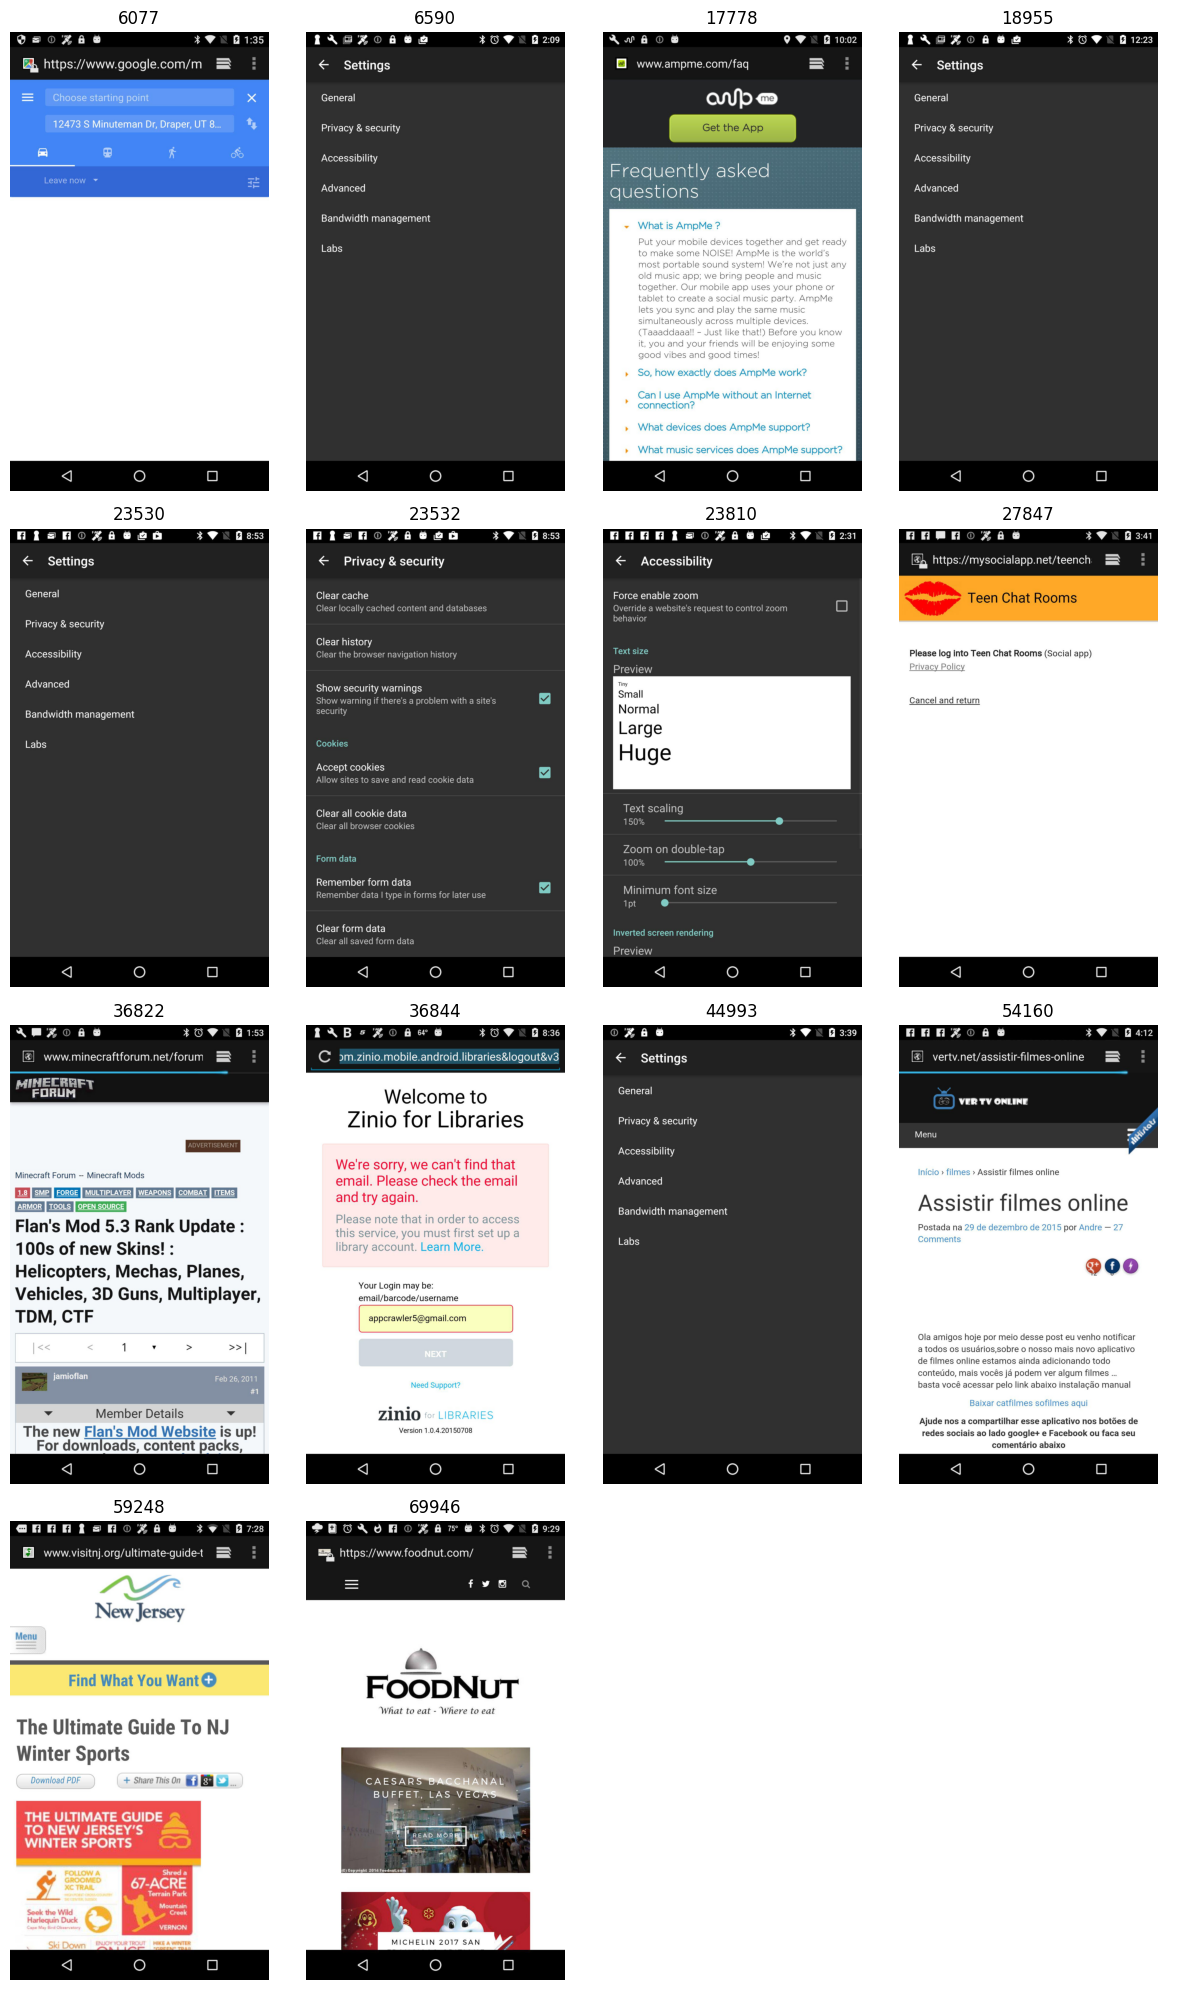

(<Figure size 1200x2000 with 16 Axes>,
 array([<Axes: title={'center': '6077'}>, <Axes: title={'center': '6590'}>,
        <Axes: title={'center': '17778'}>,
        <Axes: title={'center': '18955'}>,
        <Axes: title={'center': '23530'}>,
        <Axes: title={'center': '23532'}>,
        <Axes: title={'center': '23810'}>,
        <Axes: title={'center': '27847'}>,
        <Axes: title={'center': '36822'}>,
        <Axes: title={'center': '36844'}>,
        <Axes: title={'center': '44993'}>,
        <Axes: title={'center': '54160'}>,
        <Axes: title={'center': '59248'}>,
        <Axes: title={'center': '69946'}>, <Axes: >, <Axes: >],
       dtype=object))

In [12]:
selected_app_identifier = 'com.android.browser'

selected_df = df[df['app_identifier'] == selected_app_identifier]
display(selected_df[['screen_task_id', 'rico_id', 'task', 'app', 'app_category', 'num_comments']])
show_screen_grid(selected_df['rico_id'].unique()[:20].tolist(), max_cols=4)

Observations:
- screens with `android` identifier each belong to a different app, mostly share flows with Android system UI visible
- screens with `com.android.browser` identifier belong to the browser app; screens `6590, 18955, 23530, 44993` are identical
- screens with `com.android.gallery3d` identifier belong to the gallery/media app
- screens with `com.google.android.gms` look like Google account consent/service surfaces
- Facebook auth surfaces and some same-app repeated task groups require screen-level review before manual drops

## App Metadata Decisions

Apply app/category labels based on the app-identifier audit. `android` and Facebook auth surfaces belong to different underlying app flows, so each `rico_id` gets a distinct app label.

In [13]:
manual_app_metadata_overrides = {  # app_identifier -> (app, app_category)
    'android': (None, 'Unknown'),  # app labelled per screen below
    'com.android.browser': ('Android Browser', 'Unknown'),
    'com.android.gallery3d': ('Android Gallery', 'Video Players & Editors'),
    'com.google.android.gms': ('Google Play Services', 'Unknown'),
    'com.asanayoga.asanarebel': ('Asana Rebel', 'Health & Fitness'),
}
per_screen_app_labels = {
    'android': 'Android System Surface',
    'com.facebook.katana': 'Facebook Auth Surface',
}

for app_identifier, (app, app_category) in manual_app_metadata_overrides.items():
    df.loc[df['app_identifier'] == app_identifier, ['app', 'app_category']] = [app, app_category]
for app_identifier, label in per_screen_app_labels.items():
    mask = df['app_identifier'] == app_identifier
    df.loc[mask, 'app'] = label + ' - screen ' + df.loc[mask, 'rico_id'].astype(str)
df['app_category'] = df['app_category'].fillna('Unknown')

print(f'Unknown app categories: {(df["app_category"] == "Unknown").sum()}')

Unknown app categories: 74


## Review Reused Tasks Within App

Same task text can appear on different screens of the same app. These groups are reviewed visually before the manual drops below.

In [14]:
print(f'Task labels reused across rows: {df.loc[df["task"].duplicated(keep=False), "task"].nunique()}')

reused_task_same_app_df = (
    df.groupby(['app_identifier', 'task'])
    .agg(rows=('task', 'size'), unique_screens=('rico_id', 'nunique'), is_general_app_identifier=('is_general_app_identifier', 'first'))
    .query('rows > 1 and unique_screens > 1')
    .reset_index()
)
display(reused_task_same_app_df)

Task labels reused across rows: 47


,app_identifier,task,rows,unique_screens,is_general_app_identifier
0,com.android.browser,Manage the setting options,2,2,True
1,com.facebook.katana,Sign in with facebook account,2,2,False
2,com.healthagen.iTriage,Select an option to explore,2,2,False
3,com.thy.mobile,View flights from Aalborg to Abu Dhabi,2,2,False


com.facebook.katana | task: Sign in with facebook account


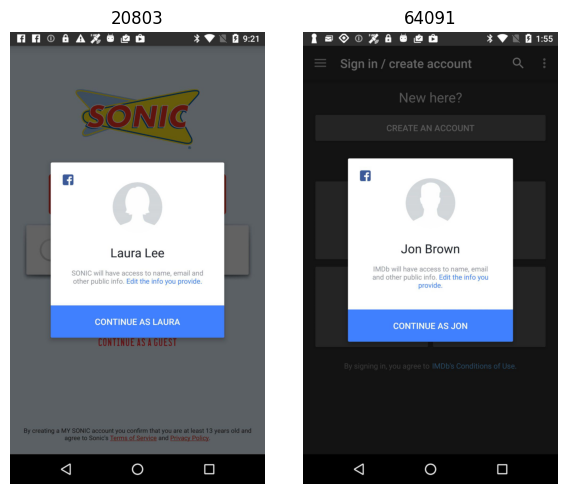

------------------------------------------------------------------------------------------------------------------------
20803_T02 | Facebook Auth Surface - screen 20803 | Sign in with facebook account | 2 comments

Comment 1 The expected standard is to ensure sufficient contrast between text and background for readability
and accessibility.  In the current design, the text has low contrast, making it difficult to read.  To fix
this, increase the contrast between the text and background by adjusting the color of the text or background.
Bounding Box: [0.19243986, 0.51718213, 0.79419626, 0.58247423]

Comment 2 The expected  standard is to include navigation options, such as a back button, to allow users to
easily return to the main screen or previous page.  In the current layout, the absence of a back button makes
it difficult for users to navigate back to the main screen.  To fix this, add a back button or other
navigation control to the layout, providing users with a clear and intuitiv

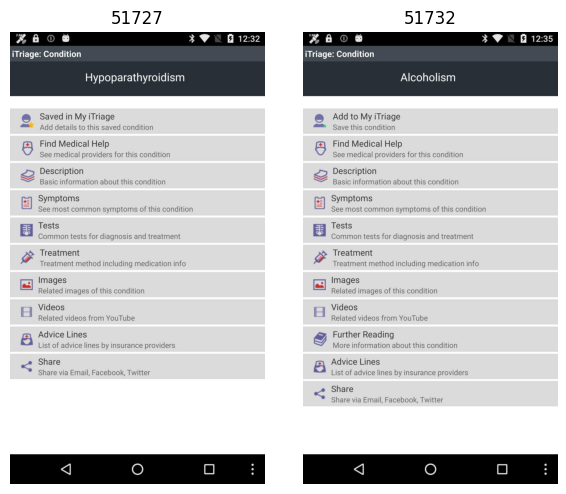

------------------------------------------------------------------------------------------------------------------------
51727_T03 | iTriage Health | Select an option to explore | 4 comments

Comment 1 The expected standard is to maintain a balanced layout that provides adequate spacing between
elements to enhance readability and visual appeal.  In the current design, there is an excessive amount of
content crammed into the layout with insufficient space between elements. To fix this,allocate more space
between the elements within the layout.  Bounding Box: [0.01792717, 0.1697479, 0.88141923, 0.77983193]

Comment 2 The expected standard is to include essential navigation elements such as a back button within
interfaces to facilitate smooth user navigation and improve overall usability.  In the current design, the
absence of a back button hinders users' ability to navigate backward within the interface effectively. To fix
this,add a back button to the layout, typically positioned in the

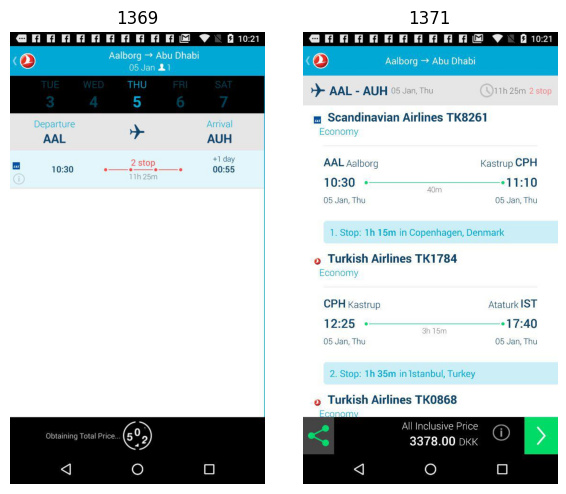

------------------------------------------------------------------------------------------------------------------------
1369_T03 | Turkish Airlines | View flights from Aalborg to Abu Dhabi | 4 comments

Comment 1 The expected standard is that nothing should be placed arbitrarily on the page.  In the current
design, these elements are placed arbitrarily and do not make sense. To fix this, omit these icons.  Bounding
Box: [0.0122184, 0.28006873, 0.05498282, 0.34879725]

Comment 2 The expected standard is that text should be easily readable.  In the current design, the text has
low contrast with the black background color. To fix this, increase the contrast between the text and the
background.  Bounding Box: [0.09774723, 0.10652921, 0.89805269, 0.17869416]

Comment 3 The expected standard is that text should be easily readable.  In the current design, the text has
low contrast with the background color. To fix this, increase the contrast between the text and the
background.  Bounding Box

In [15]:
def print_screen_comments(row, max_comments=5):
    print('-' * 120)
    print(f"{row['screen_task_id']} | {row['app']} | {row['task']} | {len(row['comments'])} comments")
    for comment in row['comments'][:max_comments]:
        print('\n' + textwrap.fill(str(comment), width=110))
    print()


for group in reused_task_same_app_df[~reused_task_same_app_df['is_general_app_identifier']].itertuples():
    rows = df[(df['app_identifier'] == group.app_identifier) & (df['task'] == group.task)]
    print('=' * 120)
    print(f'{group.app_identifier} | task: {group.task}')
    show_screen_grid(rows['rico_id'].tolist(), max_cols=4)
    for _, row in rows.iterrows():
        print_screen_comments(row)

## Manual Same-Task Decision

Record manual screen-task drops based on the reviews above. Drop by `screen_task_id` so the remaining IDs are never renumbered.

In [16]:
manual_screen_task_drop_decisions = {
    '1371_T03': 'Turkish Airlines repeated-task review; remove alternate task after retaining the matching Aalborg-Abu Dhabi flow on screen 1369.',
    '20803_T02': 'Facebook auth repeated-screen review; remove duplicate auth surface after retaining the corresponding screen 64091 flow.',
    '44993_T02': 'Browser app-identifier inspection found a repeated settings task on duplicate browser screens; retain the representative browser settings row with more comments.',
    '51727_T03': 'iTriage repeated-task review; remove duplicate health topic screen after retaining the corresponding screen 51732 flow.',
}

drop_mask = df['screen_task_id'].isin(manual_screen_task_drop_decisions)
if drop_mask.sum() != len(manual_screen_task_drop_decisions):
    raise ValueError('Some manual drop screen_task_id values were not found.')

display(df.loc[drop_mask, ['screen_task_id', 'app', 'task', 'num_comments']].assign(reason=lambda d: d['screen_task_id'].map(manual_screen_task_drop_decisions)))
df = df[~drop_mask].reset_index(drop=True)

print(f'Rows kept: {len(df)}')
print(f'Unique screens kept: {df["rico_id"].nunique()}')
print(f'Total comments kept: {df["num_comments"].sum()}')

,screen_task_id,app,task,num_comments,reason
63,1371_T03,Turkish Airlines,View flights from Aalborg to Abu Dhabi,3,Turkish Airlines repeated-task review; remove ...
879,20803_T02,Facebook Auth Surface - screen 20803,Sign in with facebook account,2,Facebook auth repeated-screen review; remove d...
1849,44993_T02,Android Browser,Manage the setting options,5,Browser app-identifier inspection found a repe...
2172,51727_T03,iTriage Health,Select an option to explore,4,iTriage repeated-task review; remove duplicate...


Rows kept: 2955
Unique screens kept: 1000
Total comments kept: 11358


# Validate Comment Sources

`comments_source` from the original dataset is not usable per comment: in some rows it is shorter than `comments`,
and where the lengths match its positions disagree with each comment's own `Comment N` / `LLM Comment N` header.
It is therefore dropped from the saved dataset; notebook 2 takes the source from the header instead.

In [17]:
is_llm_label = lambda comment: bool(re.match(r'\s*llm\s+comment', comment, re.I))
lengths_differ = df['comments'].apply(len) != df['comments_source'].apply(len)
print(f'Rows where #sources != #comments: {lengths_differ.sum()} of {len(df)}')

# Where lengths match, compare each listed source with the comment's own header
aligned = pd.DataFrame(
    [(source, 'LLM' if is_llm_label(comment) else 'Human')
     for sources, comments in df.loc[~lengths_differ, ['comments_source', 'comments']].itertuples(index=False)
     for source, comment in zip(sources, comments)],
    columns=['comments_source', 'header_label'],
)
pd.crosstab(aligned['comments_source'], aligned['header_label'], margins=True)

Rows where #sources != #comments: 82 of 2955


header_label,Human,LLM,All
comments_source,,,
both,1359,488,1847
human,6029,2147,8176
llm,788,234,1022
All,8176,2869,11045


# Save Cleaned Dataset

In [18]:
df_output = df.rename(columns={'rico_id': 'screen_id'})[
    ['screen_id', 'app_category', 'app', 'screen_task_id', 'task'] + rating_cols + ['comments']
]
df_output.to_parquet(cleaned_dir / 'uicrit_notna.parquet', index=False)
df_output.head(1)

,screen_id,app_category,app,screen_task_id,task,aesthetics_rating,learnability,efficiency,usability_rating,design_quality_rating,comments
0,15,Health & Fitness,Seven - 7 Minute Workout,15_T01,Plan and Start Full Body Workouts,6,3,3,6,6,[Comment 1\nThe expected standard is that the ...


# Encode Screen Images

Base64-encode each screen image for downstream vision-model workflows.

In [19]:
screens_df = df_output[['screen_id', 'app', 'app_category']].drop_duplicates('screen_id').sort_values('screen_id').reset_index(drop=True)
screens_df['base64_screen'] = screens_df['screen_id'].map(
    lambda screen_id: base64.b64encode((used_screens_dir / f'{screen_id}.jpg').read_bytes()).decode('utf-8')
)

screens_df.to_parquet(cleaned_dir / 'screenshots.parquet', index=False)
screens_df.head(2)

,screen_id,app,app_category,base64_screen
0,15,Seven - 7 Minute Workout,Health & Fitness,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...
1,28,Scotiabank Mobile Banking,Finance,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...


# App Coverage Summary

Summarize retained screens by app category/app, then list apps with unknown metadata.

In [20]:
screens_per_category = df_output.drop_duplicates('screen_id')['app_category'].value_counts()
print(f'Categories represented: {len(screens_per_category)}')
display(screens_per_category.rename('num_screens').reset_index())

Categories represented: 28


,app_category,num_screens
0,Health & Fitness,80
1,Shopping,78
2,Travel & Local,68
3,Social,66
4,Sports,64
5,Education,61
6,Communication,50
7,Entertainment,48
8,Weather,46
9,Books & Reference,46


In [21]:
app_screen_summary_df = (
    df_output.groupby(['app', 'app_category'])
    .agg(num_screens=('screen_id', 'nunique'), num_screen_tasks=('screen_task_id', 'size'), screen_ids=('screen_id', 'unique'))
    .reset_index()
)
print(f'Apps represented: {app_screen_summary_df["app"].nunique()}')
display(app_screen_summary_df)
display(app_screen_summary_df[app_screen_summary_df['app_category'] == 'Unknown'])

Apps represented: 871


,app,app_category,num_screens,num_screen_tasks,screen_ids
0,"1,000,000 Wallpapers HD",Entertainment,1,3,[34070]
1,10 Daily Exercises,Health & Fitness,1,3,[8255]
2,13News Now (WVEC),News & Magazines,1,3,[63844]
3,1Q,Business,1,3,[69556]
4,21 Day Tracker Free Body Fix,Health & Fitness,2,6,"[19170, 19184]"
...,...,...,...,...,...
866,nearme – Buy and Sell locally,Shopping,1,3,[63584]
867,redBus - Bus and Hotel Booking,Travel & Local,3,8,"[44308, 44323, 44324]"
868,theScore esports,Sports,1,3,[10805]
869,your Baby - Make a baby!,Entertainment,1,3,[22172]


,app,app_category,num_screens,num_screen_tasks,screen_ids
30,Android Browser,Unknown,14,41,"[6077, 6590, 17778, 18955, 23530, 23532, 23810..."
33,Android System Surface - screen 14829,Unknown,1,3,[14829]
34,Android System Surface - screen 18137,Unknown,1,3,[18137]
35,Android System Surface - screen 19258,Unknown,1,3,[19258]
36,Android System Surface - screen 25535,Unknown,1,3,[25535]
37,Android System Surface - screen 28283,Unknown,1,3,[28283]
38,Android System Surface - screen 2879,Unknown,1,2,[2879]
39,Android System Surface - screen 342,Unknown,1,3,[342]
40,Android System Surface - screen 36234,Unknown,1,3,[36234]
293,Google Play Services,Unknown,3,9,"[34639, 47689, 68689]"


# Dataset Statistics

Summarize the final screen-task dataset after preprocessing.

In [22]:
df_output.describe()

,screen_id,aesthetics_rating,learnability,efficiency,usability_rating,design_quality_rating
count,2955.000000,2955.000000,2955.000000,2955.000000,2955.000000,2955.000000
mean,35934.769205,5.746193,3.007445,3.017259,5.814890,5.814890
std,20930.620647,1.087512,0.611290,0.652094,1.065515,1.020399
min,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,17259.000000,5.000000,3.000000,3.000000,5.000000,5.000000
50%,36234.000000,6.000000,3.000000,3.000000,6.000000,6.000000
75%,53493.500000,6.000000,3.000000,3.000000,6.000000,6.000000
max,72194.000000,10.000000,5.000000,5.000000,10.000000,9.000000


## Display Example

Show one screen-task example with its comments and a bounding box overlay.

Task: Tap on the Plus icon or explore the Workout Plans. 

Comment 1 The expected standard is to make the most important information visually dominant. In the
current design, the back button is not visually prominent. To fix this, we can enlarge the back
button. Bounding Box: [0.02777819, 0.04375018, 0.10555714, 0.10937545] 

Comment 2 The expected standard is to make the most important information visually dominant. In the
current design, the highlighted heading is not visually prominent. To fix this, we can enlarge the
text. Bounding Box: [0.0138891, 0.13906307, 0.1861139, 0.1953133] 

Comment 3 The expected standard is to make the most important information visually dominant. In the
current design, the highlighted heading is not visually prominent. To fix this, we can enlarge the
text. Bounding Box: [0.01666692, 0.5375022, 0.28889322, 0.59375243] 

Comment 4 The expected standard is to make the most important information visually dominant. In the
current design, the highlighted icon

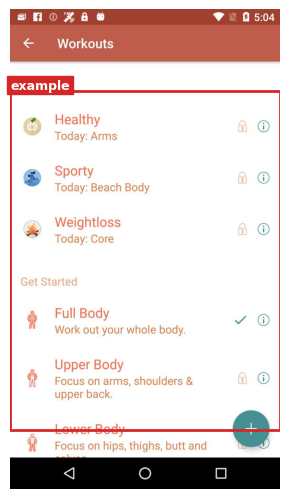

(<Figure size 300x533.333 with 1 Axes>, <Axes: >)

In [23]:
example = df_output.iloc[1]
print('Task:', example['task'], '\n')
for comment in example['comments']:
    print(textwrap.fill(comment, width=100), '\n')

show_screen(screen_id=example['screen_id'], bboxes=[0.0, 0.1697479, 1.0, 0.876037], labels=['example'])

## Repeated Screens and Ratings

Check whether screens with multiple tasks also have different rating values across tasks.

In [24]:
tasks_per_screen = df_output['screen_id'].value_counts()
rating_varies = df_output.groupby('screen_id')[rating_cols].nunique().gt(1).any(axis=1)

print(f'Number of repeated screens: {(tasks_per_screen > 1).sum()}')
print(f'Maximum number of times a screen is repeated: {tasks_per_screen.max()}')
print(f'Number of repeated screens with different individual ratings: {rating_varies.sum()}')

Number of repeated screens: 998
Maximum number of times a screen is repeated: 4
Number of repeated screens with different individual ratings: 955


## Usability Rating Check

Check how often `usability_rating` equals `learnability + efficiency`.

In [25]:
matches = (df_output['usability_rating'] == df_output['learnability'] + df_output['efficiency'])
print(f'Out of {len(matches)} expert ratings, {matches.sum()} ({matches.mean() * 100:.2f}%) have usability_rating equal to learnability + efficiency.')

Out of 2955 expert ratings, 2541 (85.99%) have usability_rating equal to learnability + efficiency.
